In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

In [8]:
# load store dataset

df_store = pd.read_csv(
    "https://raw.githubusercontent.com/mahak-b/Retail_sales_forecasting/main/stores_data_set.csv"
)
df_store

,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875
5,6,A,202505
6,7,B,70713
7,8,A,155078
8,9,B,125833
9,10,B,126512


In [9]:
df_store.isnull().sum()

Store    0
Type     0
Size     0
dtype: int64

In [10]:
# load sales dataset
df_sales = pd.read_csv(
    "https://raw.githubusercontent.com/mahak-b/Retail_sales_forecasting/main/sales_data_set.csv"
)
df_sales

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,05/02/2010,24924.50,False
1,1,1,12/02/2010,46039.49,True
2,1,1,19/02/2010,41595.55,False
3,1,1,26/02/2010,19403.54,False
4,1,1,05/03/2010,21827.90,False
...,...,...,...,...,...
421565,45,98,28/09/2012,508.37,False
421566,45,98,05/10/2012,628.10,False
421567,45,98,12/10/2012,1061.02,False
421568,45,98,19/10/2012,760.01,False


In [11]:
df_sales.isnull().sum()

Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
dtype: int64

In [12]:

# load features dataset
df_feature = pd.read_csv(
    "https://raw.githubusercontent.com/mahak-b/Retail_sales_forecasting/main/Features_data_set.csv"
)
df_feature

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,05/02/2010,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,12/02/2010,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,19/02/2010,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,26/02/2010,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,05/03/2010,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False
...,...,...,...,...,...,...,...,...,...,...,...,...
8185,45,28/06/2013,76.05,3.639,4842.29,975.03,3.00,2449.97,3169.69,NaN,NaN,False
8186,45,05/07/2013,77.50,3.614,9090.48,2268.58,582.74,5797.47,1514.93,NaN,NaN,False
8187,45,12/07/2013,79.37,3.614,3789.94,1827.31,85.72,744.84,2150.36,NaN,NaN,False
8188,45,19/07/2013,82.84,3.737,2961.49,1047.07,204.19,363.00,1059.46,NaN,NaN,False


In [13]:

df_feature.isnull().sum()

Store              0
Date               0
Temperature        0
Fuel_Price         0
MarkDown1       4158
MarkDown2       5269
MarkDown3       4577
MarkDown4       4726
MarkDown5       4140
CPI              585
Unemployment     585
IsHoliday          0
dtype: int64

In [14]:
# combine store and sales dataframe into single dataframe based on 'store' column
df1 = pd.merge(df_sales, df_store, on='Store', how='inner')
df1

,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size
0,1,1,05/02/2010,24924.50,False,A,151315
1,1,1,12/02/2010,46039.49,True,A,151315
2,1,1,19/02/2010,41595.55,False,A,151315
3,1,1,26/02/2010,19403.54,False,A,151315
4,1,1,05/03/2010,21827.90,False,A,151315
...,...,...,...,...,...,...,...
421565,45,98,28/09/2012,508.37,False,B,118221
421566,45,98,05/10/2012,628.10,False,B,118221
421567,45,98,12/10/2012,1061.02,False,B,118221
421568,45,98,19/10/2012,760.01,False,B,118221


In [15]:
# combine store and feature dataframe into single datarame based on 'store' column
df2 = pd.merge(df_store, df_feature, on='Store', how='inner')
df2

,Store,Type,Size,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,A,151315,05/02/2010,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,A,151315,12/02/2010,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,A,151315,19/02/2010,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,A,151315,26/02/2010,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,A,151315,05/03/2010,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8185,45,B,118221,28/06/2013,76.05,3.639,4842.29,975.03,3.00,2449.97,3169.69,NaN,NaN,False
8186,45,B,118221,05/07/2013,77.50,3.614,9090.48,2268.58,582.74,5797.47,1514.93,NaN,NaN,False
8187,45,B,118221,12/07/2013,79.37,3.614,3789.94,1827.31,85.72,744.84,2150.36,NaN,NaN,False
8188,45,B,118221,19/07/2013,82.84,3.737,2961.49,1047.07,204.19,363.00,1059.46,NaN,NaN,False


In [16]:

# create unique column (diff) for the combination of store and date
df1['diff'] = df1['Store'].astype(str) + '-' + df1['Date']
df2['diff'] = df2['Store'].astype(str) + '-' + df2['Date']

In [17]:
df1.sample(5)

,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,diff
161775,17,32,24/06/2011,6292.32,False,B,93188,17-24/06/2011
32063,4,19,24/08/2012,2499.56,False,A,205863,4-24/08/2012
104105,11,52,08/04/2011,2609.18,False,A,207499,11-08/04/2011
288939,30,20,20/04/2012,120.00,False,C,42988,30-20/04/2012
367968,39,60,13/08/2010,0.00,False,A,184109,39-13/08/2010


In [18]:
# df1 contains records from 2010 through October 2012.
# df2 contains records from 2010 through 2013.
# Split df2 into:
#   - 2010 to October 2012
#   - November 2012 to 2013
# Append the first portion (2010 to October 2012) to df1.

In [19]:

# make list with diff column for df1
df1_list = df1['diff'].to_list()

In [20]:

# filter 2010 to 2012-oct data from df2 based on df1_list
df2_inlist = df2[df2['diff'].isin(df1_list)]
df2_inlist.reset_index(drop=True, inplace=True)
df2_inlist.tail(5)

,Store,Type,Size,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday,diff
6430,45,B,118221,28/09/2012,64.88,3.997,4556.61,20.64,1.50,1601.01,3288.25,192.013558,8.684,False,45-28/09/2012
6431,45,B,118221,05/10/2012,64.89,3.985,5046.74,NaN,18.82,2253.43,2340.01,192.170412,8.667,False,45-05/10/2012
6432,45,B,118221,12/10/2012,54.47,4.000,1956.28,NaN,7.89,599.32,3990.54,192.327265,8.667,False,45-12/10/2012
6433,45,B,118221,19/10/2012,56.47,3.969,2004.02,NaN,3.18,437.73,1537.49,192.330854,8.667,False,45-19/10/2012
6434,45,B,118221,26/10/2012,58.85,3.882,4018.91,58.08,100.00,211.94,858.33,192.308899,8.667,False,45-26/10/2012


In [21]:
# anther filter for 2012-oct to 2013 data from df2 not in df1_list (~)
df2_notinlist = df2[~df2['diff'].isin(df1_list)]
df2_notinlist.reset_index(drop=True, inplace=True)
df2_notinlist.tail(5)

,Store,Type,Size,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday,diff
1750,45,B,118221,28/06/2013,76.05,3.639,4842.29,975.03,3.00,2449.97,3169.69,NaN,NaN,False,45-28/06/2013
1751,45,B,118221,05/07/2013,77.50,3.614,9090.48,2268.58,582.74,5797.47,1514.93,NaN,NaN,False,45-05/07/2013
1752,45,B,118221,12/07/2013,79.37,3.614,3789.94,1827.31,85.72,744.84,2150.36,NaN,NaN,False,45-12/07/2013
1753,45,B,118221,19/07/2013,82.84,3.737,2961.49,1047.07,204.19,363.00,1059.46,NaN,NaN,False,45-19/07/2013
1754,45,B,118221,26/07/2013,76.06,3.804,212.02,851.73,2.06,10.88,1864.57,NaN,NaN,False,45-26/07/2013


In [22]:
df2.shape, df2_inlist.shape, df2_notinlist.shape

((8190, 15), (6435, 15), (1755, 15))

In [23]:

df2['diff'].nunique(), df2_inlist['diff'].nunique(), df2_notinlist['diff'].nunique()

(8190, 6435, 1755)

In [24]:

# merge df1 and df2(2010 to 2012-oct) data based on 'diff' column
# 'inner' - merge columns based on exact 'diff' in both dataframes

df3 = pd.merge(df1, df2_inlist, on='diff', how='inner')
df3.tail()

,Store_x,Dept,Date_x,Weekly_Sales,IsHoliday_x,Type_x,Size_x,diff,Store_y,Type_y,Size_y,Date_y,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday_y
421565,45,98,28/09/2012,508.37,False,B,118221,45-28/09/2012,45,B,118221,28/09/2012,64.88,3.997,4556.61,20.64,1.50,1601.01,3288.25,192.013558,8.684,False
421566,45,98,05/10/2012,628.10,False,B,118221,45-05/10/2012,45,B,118221,05/10/2012,64.89,3.985,5046.74,NaN,18.82,2253.43,2340.01,192.170412,8.667,False
421567,45,98,12/10/2012,1061.02,False,B,118221,45-12/10/2012,45,B,118221,12/10/2012,54.47,4.000,1956.28,NaN,7.89,599.32,3990.54,192.327265,8.667,False
421568,45,98,19/10/2012,760.01,False,B,118221,45-19/10/2012,45,B,118221,19/10/2012,56.47,3.969,2004.02,NaN,3.18,437.73,1537.49,192.330854,8.667,False
421569,45,98,26/10/2012,1076.80,False,B,118221,45-26/10/2012,45,B,118221,26/10/2012,58.85,3.882,4018.91,58.08,100.00,211.94,858.33,192.308899,8.667,False


In [25]:
# drop the duplicate columns and rename it
df3.drop(columns=['Store_y','Type_y','Size_y','Date_y','IsHoliday_y'], inplace=True)
df3.rename(columns={'Store_x':'Store', 'Date_x':'Date', 'IsHoliday_x':'IsHoliday', 'Type_x':'Type', 'Size_x':'Size'}, inplace=True)

In [26]:

df3.tail(3)

,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,diff,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
421567,45,98,12/10/2012,1061.02,False,B,118221,45-12/10/2012,54.47,4.000,1956.28,NaN,7.89,599.32,3990.54,192.327265,8.667
421568,45,98,19/10/2012,760.01,False,B,118221,45-19/10/2012,56.47,3.969,2004.02,NaN,3.18,437.73,1537.49,192.330854,8.667
421569,45,98,26/10/2012,1076.80,False,B,118221,45-26/10/2012,58.85,3.882,4018.91,58.08,100.00,211.94,858.33,192.308899,8.667


In [27]:
# 2012-nov to 2013 dataframe
df2_notinlist.tail(3)

,Store,Type,Size,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday,diff
1752,45,B,118221,12/07/2013,79.37,3.614,3789.94,1827.31,85.72,744.84,2150.36,NaN,NaN,False,45-12/07/2013
1753,45,B,118221,19/07/2013,82.84,3.737,2961.49,1047.07,204.19,363.00,1059.46,NaN,NaN,False,45-19/07/2013
1754,45,B,118221,26/07/2013,76.06,3.804,212.02,851.73,2.06,10.88,1864.57,NaN,NaN,False,45-26/07/2013


In [28]:

# df1: 2010–Oct 2012 (Store, Date, Dept)
# df2_notinlist: Nov 2012–2013 (Store, Date only)

# Expand df2_notinlist to include department-wise entries.
# Extract the Store–Dept mapping from the sales dataset.

s = df_sales[['Store','Dept']]
s

,Store,Dept
0,1,1
1,1,1
2,1,1
3,1,1
4,1,1
...,...,...
421565,45,98
421566,45,98
421567,45,98
421568,45,98


In [29]:
# remove duplicates from the combination of 'store' and 'dept'

s.drop_duplicates(subset=['Store', 'Dept'], inplace=True)
s.reset_index(drop=True, inplace=True)
s

,Store,Dept
0,1,1
1,1,2
2,1,3
3,1,4
4,1,5
...,...,...
3326,45,94
3327,45,95
3328,45,96
3329,45,97


In [30]:


df4 = pd.merge(s, df2_notinlist, on='Store', how='outer')
df4.tail()

,Store,Dept,Type,Size,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday,diff
129904,45,98,B,118221,28/06/2013,76.05,3.639,4842.29,975.03,3.00,2449.97,3169.69,NaN,NaN,False,45-28/06/2013
129905,45,98,B,118221,05/07/2013,77.50,3.614,9090.48,2268.58,582.74,5797.47,1514.93,NaN,NaN,False,45-05/07/2013
129906,45,98,B,118221,12/07/2013,79.37,3.614,3789.94,1827.31,85.72,744.84,2150.36,NaN,NaN,False,45-12/07/2013
129907,45,98,B,118221,19/07/2013,82.84,3.737,2961.49,1047.07,204.19,363.00,1059.46,NaN,NaN,False,45-19/07/2013
129908,45,98,B,118221,26/07/2013,76.06,3.804,212.02,851.73,2.06,10.88,1864.57,NaN,NaN,False,45-26/07/2013


In [31]:

# concatinate (2010 to 2013)

df5 = pd.concat([df3, df4])
df5.reset_index(drop=True, inplace=True)
df5.tail()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,diff,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
551474,45,98,28/06/2013,NaN,False,B,118221,45-28/06/2013,76.05,3.639,4842.29,975.03,3.00,2449.97,3169.69,NaN,NaN
551475,45,98,05/07/2013,NaN,False,B,118221,45-05/07/2013,77.50,3.614,9090.48,2268.58,582.74,5797.47,1514.93,NaN,NaN
551476,45,98,12/07/2013,NaN,False,B,118221,45-12/07/2013,79.37,3.614,3789.94,1827.31,85.72,744.84,2150.36,NaN,NaN
551477,45,98,19/07/2013,NaN,False,B,118221,45-19/07/2013,82.84,3.737,2961.49,1047.07,204.19,363.00,1059.46,NaN,NaN
551478,45,98,26/07/2013,NaN,False,B,118221,45-26/07/2013,76.06,3.804,212.02,851.73,2.06,10.88,1864.57,NaN,NaN


In [32]:
# Datatype conversion using pandas
df5['Date'] = df5['Date'].apply(lambda x: x.replace('/','-'))
df5['Date'] = pd.to_datetime(df5['Date'], format='%d-%m-%Y', errors='coerce')

# encoding for catagorical features into numerical
df5['IsHoliday'] = df5['IsHoliday'].map({True:1, False:0})
df5['Type'] = df5['Type'].map({'A':1, 'B':2, 'C':3})

df5.tail(3)

,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,diff,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
551476,45,98,2013-07-12,NaN,0,2,118221,45-12/07/2013,79.37,3.614,3789.94,1827.31,85.72,744.84,2150.36,NaN,NaN
551477,45,98,2013-07-19,NaN,0,2,118221,45-19/07/2013,82.84,3.737,2961.49,1047.07,204.19,363.00,1059.46,NaN,NaN
551478,45,98,2013-07-26,NaN,0,2,118221,45-26/07/2013,76.06,3.804,212.02,851.73,2.06,10.88,1864.57,NaN,NaN


In [33]:
# drop 'diff' column and sort the dataframe in ascending order

df5.drop(columns=['diff'], inplace=True)

df5 = df5.sort_values(by=['Date','Store','Dept'])
df5.reset_index(drop=True, inplace=True)

df5.tail()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
551474,45,94,2013-07-26,NaN,0,2,118221,76.06,3.804,212.02,851.73,2.06,10.88,1864.57,NaN,NaN
551475,45,95,2013-07-26,NaN,0,2,118221,76.06,3.804,212.02,851.73,2.06,10.88,1864.57,NaN,NaN
551476,45,96,2013-07-26,NaN,0,2,118221,76.06,3.804,212.02,851.73,2.06,10.88,1864.57,NaN,NaN
551477,45,97,2013-07-26,NaN,0,2,118221,76.06,3.804,212.02,851.73,2.06,10.88,1864.57,NaN,NaN
551478,45,98,2013-07-26,NaN,0,2,118221,76.06,3.804,212.02,851.73,2.06,10.88,1864.57,NaN,NaN


In [34]:
# Day,Month,Year new features and drop Date column

df5['Day'] = df5['Date'].dt.day
df5['Month'] = df5['Date'].dt.month
df5['Year'] = df5['Date'].dt.year
df5.drop(columns=['Date'], inplace=True)
df5


,Store,Dept,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Day,Month,Year
0,1,1,24924.50,0,1,151315,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,5,2,2010
1,1,2,50605.27,0,1,151315,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,5,2,2010
2,1,3,13740.12,0,1,151315,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,5,2,2010
3,1,4,39954.04,0,1,151315,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,5,2,2010
4,1,5,32229.38,0,1,151315,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,5,2,2010
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
551474,45,94,NaN,0,2,118221,76.06,3.804,212.02,851.73,2.06,10.88,1864.57,NaN,NaN,26,7,2013
551475,45,95,NaN,0,2,118221,76.06,3.804,212.02,851.73,2.06,10.88,1864.57,NaN,NaN,26,7,2013
551476,45,96,NaN,0,2,118221,76.06,3.804,212.02,851.73,2.06,10.88,1864.57,NaN,NaN,26,7,2013
551477,45,97,NaN,0,2,118221,76.06,3.804,212.02,851.73,2.06,10.88,1864.57,NaN,NaN,26,7,2013


In [35]:

# rearrange the columns order

df5 = df5[['Day','Month','Year','Store','Dept','Type','Weekly_Sales','Size','IsHoliday','Temperature',
           'Fuel_Price', 'MarkDown1', 'MarkDown2','MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment']]
df5.tail()

,Day,Month,Year,Store,Dept,Type,Weekly_Sales,Size,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
551474,26,7,2013,45,94,2,NaN,118221,0,76.06,3.804,212.02,851.73,2.06,10.88,1864.57,NaN,NaN
551475,26,7,2013,45,95,2,NaN,118221,0,76.06,3.804,212.02,851.73,2.06,10.88,1864.57,NaN,NaN
551476,26,7,2013,45,96,2,NaN,118221,0,76.06,3.804,212.02,851.73,2.06,10.88,1864.57,NaN,NaN
551477,26,7,2013,45,97,2,NaN,118221,0,76.06,3.804,212.02,851.73,2.06,10.88,1864.57,NaN,NaN
551478,26,7,2013,45,98,2,NaN,118221,0,76.06,3.804,212.02,851.73,2.06,10.88,1864.57,NaN,NaN


In [36]:
df5.isnull().sum()

Day                  0
Month                0
Year                 0
Store                0
Dept                 0
Type                 0
Weekly_Sales    129909
Size                 0
IsHoliday            0
Temperature          0
Fuel_Price           0
MarkDown1       271074
MarkDown2       343582
MarkDown3       296860
MarkDown4       302830
MarkDown5       270138
CPI              43303
Unemployment     43303
dtype: int64

In [37]:
df5.describe().T

,count,mean,std,min,25%,50%,75%,max
Day,551479.0,15.653488,8.776044,1.000,8.000000,16.000000,23.000000,31.000000
Month,551479.0,6.277180,3.340134,1.000,3.000000,6.000000,9.000000,12.000000
Year,551479.0,2011.392758,1.054086,2010.000,2010.000000,2011.000000,2012.000000,2013.000000
Store,551479.0,22.270485,12.796872,1.000,11.000000,22.000000,33.000000,45.000000
Dept,551479.0,44.603013,30.416079,1.000,19.000000,38.000000,74.000000,99.000000
Type,551479.0,1.594791,0.669624,1.000,1.000000,1.000000,2.000000,3.000000
Weekly_Sales,421570.0,15981.258123,22711.183519,-4988.940,2079.650000,7612.030000,20205.852500,693099.360000
Size,551479.0,136073.691863,61207.331445,34875.000,93638.000000,128107.000000,202505.000000,219622.000000
IsHoliday,551479.0,0.071905,0.258330,0.000,0.000000,0.000000,0.000000,1.000000
Temperature,551479.0,58.703624,18.685408,-7.290,45.160000,59.940000,73.160000,101.950000


In [38]:

# check negative weekly_sales count
df5[df5['Weekly_Sales']<=0]

,Day,Month,Year,Store,Dept,Type,Weekly_Sales,Size,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
389,5,2,2010,6,47,1,-59.00,202505,0,40.43,2.572,NaN,NaN,NaN,NaN,NaN,212.622352,7.259
601,5,2,2010,9,49,2,-15.00,125833,0,38.01,2.572,NaN,NaN,NaN,NaN,NaN,214.655459,6.415
714,5,2,2010,11,19,1,0.00,207499,0,46.04,2.572,NaN,NaN,NaN,NaN,NaN,214.424881,7.368
1039,5,2,2010,15,80,2,-0.04,123737,0,19.83,2.954,NaN,NaN,NaN,NaN,NaN,131.527903,8.350
1345,5,2,2010,20,19,1,0.00,203742,0,25.92,2.784,NaN,NaN,NaN,NaN,NaN,204.247194,8.187
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
419896,26,10,2012,19,47,1,-18.00,203819,0,56.49,4.071,5430.75,90.07,NaN,904.34,1665.77,138.728161,7.992
419943,26,10,2012,20,19,1,-3.97,203742,0,60.04,3.882,10813.19,22.33,102.91,867.39,1671.76,216.151590,7.293
420601,26,10,2012,29,80,2,-178.15,93638,0,57.58,3.917,5581.80,2.98,NaN,398.23,396.11,138.728161,9.151
420972,26,10,2012,35,80,2,-16.51,103681,0,58.99,3.882,6221.06,42.48,103.00,273.90,996.79,142.762411,8.665


In [39]:
# negative weekly_sales value convert to null value

df5['Weekly_Sales'] = df5['Weekly_Sales'].apply(lambda x: np.nan if x<=0 else x)
df5.tail()

,Day,Month,Year,Store,Dept,Type,Weekly_Sales,Size,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
551474,26,7,2013,45,94,2,NaN,118221,0,76.06,3.804,212.02,851.73,2.06,10.88,1864.57,NaN,NaN
551475,26,7,2013,45,95,2,NaN,118221,0,76.06,3.804,212.02,851.73,2.06,10.88,1864.57,NaN,NaN
551476,26,7,2013,45,96,2,NaN,118221,0,76.06,3.804,212.02,851.73,2.06,10.88,1864.57,NaN,NaN
551477,26,7,2013,45,97,2,NaN,118221,0,76.06,3.804,212.02,851.73,2.06,10.88,1864.57,NaN,NaN
551478,26,7,2013,45,98,2,NaN,118221,0,76.06,3.804,212.02,851.73,2.06,10.88,1864.57,NaN,NaN


In [40]:
df5.isnull().sum()

Day                  0
Month                0
Year                 0
Store                0
Dept                 0
Type                 0
Weekly_Sales    131267
Size                 0
IsHoliday            0
Temperature          0
Fuel_Price           0
MarkDown1       271074
MarkDown2       343582
MarkDown3       296860
MarkDown4       302830
MarkDown5       270138
CPI              43303
Unemployment     43303
dtype: int64

In [41]:
# MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5 - features have huge number of null values compare to other features

In [42]:
# Add a 'markdown' flag based on markdown columns:
# Set to 0 when all markdown values are missing, else set to 1.

df5['markdown'] = df5[['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5']].notnull().any(axis=1).astype(int)
df5

,Day,Month,Year,Store,Dept,Type,Weekly_Sales,Size,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,markdown
0,5,2,2010,1,1,1,24924.50,151315,0,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,0
1,5,2,2010,1,2,1,50605.27,151315,0,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,0
2,5,2,2010,1,3,1,13740.12,151315,0,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,0
3,5,2,2010,1,4,1,39954.04,151315,0,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,0
4,5,2,2010,1,5,1,32229.38,151315,0,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
551474,26,7,2013,45,94,2,NaN,118221,0,76.06,3.804,212.02,851.73,2.06,10.88,1864.57,NaN,NaN,1
551475,26,7,2013,45,95,2,NaN,118221,0,76.06,3.804,212.02,851.73,2.06,10.88,1864.57,NaN,NaN,1
551476,26,7,2013,45,96,2,NaN,118221,0,76.06,3.804,212.02,851.73,2.06,10.88,1864.57,NaN,NaN,1
551477,26,7,2013,45,97,2,NaN,118221,0,76.06,3.804,212.02,851.73,2.06,10.88,1864.57,NaN,NaN,1


In [43]:
# check weekly_sales average --> holiday(1) and non-holiday(0)
df5.groupby('markdown')['Weekly_Sales'].mean()

markdown
0    15922.137810
1    16231.116041
Name: Weekly_Sales, dtype: float64

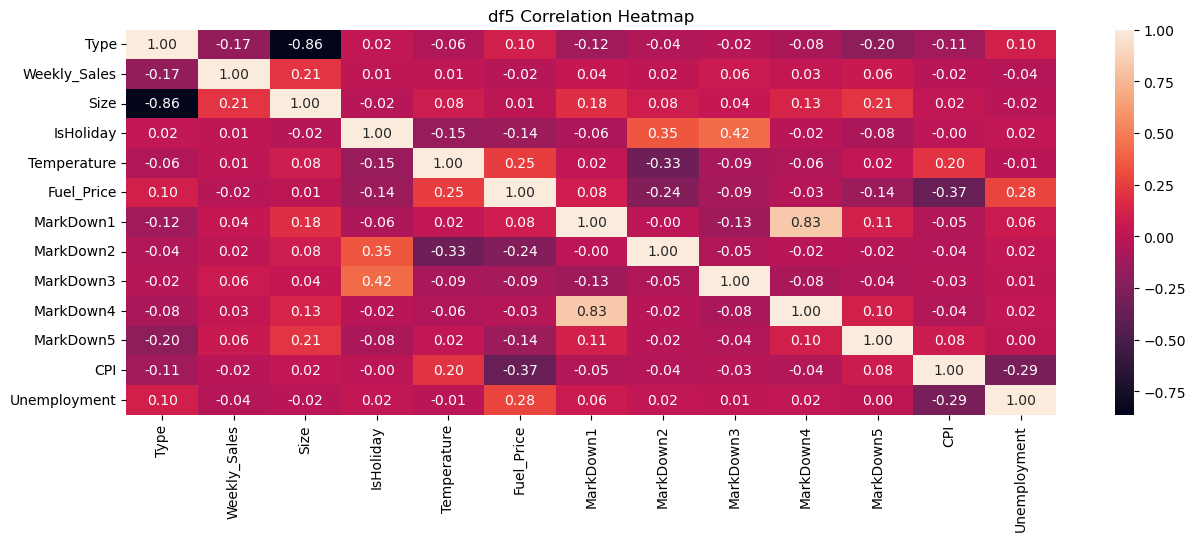

In [44]:
df5_corr = df5.drop(columns=['Day', 'Month', 'Year', 'Store', 'Dept','markdown']).dropna().corr()

# Create a heatmap
plt.figure(figsize=(15, 5))  # Adjust the figure size if needed
sns.heatmap(df5_corr, annot=True, fmt=".2f")
plt.title("df5 Correlation Heatmap")
plt.show()

In [46]:
df5['diff'] = df5['Day'].astype(str)+df5['Month'].astype(str)+df5['Year'].astype(str)+'-'+df5['Store'].astype(str)+'-'+df5['Dept'].astype(str)
df5.tail()

,Day,Month,Year,Store,Dept,Type,Weekly_Sales,Size,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,markdown,diff
551474,26,7,2013,45,94,2,NaN,118221,0,76.06,3.804,212.02,851.73,2.06,10.88,1864.57,NaN,NaN,1,2672013-45-94
551475,26,7,2013,45,95,2,NaN,118221,0,76.06,3.804,212.02,851.73,2.06,10.88,1864.57,NaN,NaN,1,2672013-45-95
551476,26,7,2013,45,96,2,NaN,118221,0,76.06,3.804,212.02,851.73,2.06,10.88,1864.57,NaN,NaN,1,2672013-45-96
551477,26,7,2013,45,97,2,NaN,118221,0,76.06,3.804,212.02,851.73,2.06,10.88,1864.57,NaN,NaN,1,2672013-45-97
551478,26,7,2013,45,98,2,NaN,118221,0,76.06,3.804,212.02,851.73,2.06,10.88,1864.57,NaN,NaN,1,2672013-45-98


In [47]:
# MarkDown1–MarkDown5 have a high proportion of missing values.

# Develop two forecasting models for Weekly_Sales:
# - Model 1: Include MarkDown1–MarkDown5.
# - Model 2: Exclude MarkDown1–MarkDown5.

# Evaluate and compare both models to measure the contribution
# of the markdown features.

In [48]:
df5.nunique()

Day                 31
Month               12
Year                 4
Store               45
Dept                81
Type                 3
Weekly_Sales    358785
Size                40
IsHoliday            2
Temperature       4178
Fuel_Price        1011
MarkDown1         4023
MarkDown2         2715
MarkDown3         2885
MarkDown4         3405
MarkDown5         4045
CPI               2505
Unemployment       404
markdown             2
diff            551479
dtype: int64

# Method 1 - with Markdown

In [49]:
!pip install XGBoost

In [50]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor

In [51]:
# Build a complete-case DataFrame using only non-null records.

# Train individual models to predict each of the following features:
# - MarkDown1 to MarkDown5
# - CPI
# - Unemployment

# Use the predictions to populate missing values in the original
# DataFrame according to the 'diff' column.

# Once all missing values are imputed, train the final model
# for Weekly_Sales prediction.

In [52]:
def algorithm_train_test_accuracy(x_train, x_test, y_train, y_test, algorithm):

    model = algorithm().fit(x_train, y_train)
    y_pred_train = model.predict(x_train)
    y_pred_test = model.predict(x_test)
    r2_train = r2_score(y_train, y_pred_train)
    r2_test = r2_score(y_test, y_pred_test)

    # algo = str(algorithm).split("'")[1].split(".")[-1]
    accuracy = {'algorithm': algorithm.__name__,
                'R2_train' : r2_train,
                'R2_test'  : r2_test}

    return accuracy

In [53]:
# check different algorithms and predict null values using best algorithm
def ml_regression(df, null_features, label):

    # only label column with null values and drop the other null columns from df
    df = df.drop(columns=null_features)

    # filter null values into separate dataframe and reset index order
    df_null = df[df[label].isnull()]
    df_null.reset_index(drop=True, inplace=True)

    # also filter non-null values into separate dataframe and reset index order
    df_notnull = df[df[label].notnull()]
    df_notnull.reset_index(drop=True, inplace=True)

    # make vector(x) and label(y) variables
    x = df_notnull.drop(columns=[label, 'diff'], axis=1)
    y = df_notnull[label]
    x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

    # calculate Training and Testing accuracy of different algorithms and evaluate model performance using metrics
    print(algorithm_train_test_accuracy(x_train, x_test, y_train, y_test, DecisionTreeRegressor))
    print(algorithm_train_test_accuracy(x_train, x_test, y_train, y_test, ExtraTreesRegressor))
    print(algorithm_train_test_accuracy(x_train, x_test, y_train, y_test, RandomForestRegressor))
    print(algorithm_train_test_accuracy(x_train, x_test, y_train, y_test, AdaBoostRegressor))
    print(algorithm_train_test_accuracy(x_train, x_test, y_train, y_test, GradientBoostingRegressor))
    print(algorithm_train_test_accuracy(x_train, x_test, y_train, y_test, XGBRegressor))

    # Random Forest algorithm performs well to predict unseen data
    model = RandomForestRegressor().fit(x_train, y_train)
    y_pred = model.predict(x_test)

    # evaluate model performance using metrics
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)

    metrics = {'R2': r2,
              'Mean Absolute Error': mae,
              'Mean Squared Error': mse,
              'Root Mean Squared Error': rmse}
    print(metrics)

    # predict null values using model
    y_pred = model.predict(df_null.drop(columns=[label, 'diff'], axis=1))

    # make dataframe of predicted label value and merge with non-null values
    df_null[label] = pd.DataFrame(y_pred)
    df_final = pd.concat([df_null,df_notnull], axis=0, ignore_index=True)
    return df_final


In [54]:
df_m1 = df5.copy()
df_m1.drop(columns=['markdown'],inplace=True)
df_m1.tail()



,Day,Month,Year,Store,Dept,Type,Weekly_Sales,Size,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,diff
551474,26,7,2013,45,94,2,NaN,118221,0,76.06,3.804,212.02,851.73,2.06,10.88,1864.57,NaN,NaN,2672013-45-94
551475,26,7,2013,45,95,2,NaN,118221,0,76.06,3.804,212.02,851.73,2.06,10.88,1864.57,NaN,NaN,2672013-45-95
551476,26,7,2013,45,96,2,NaN,118221,0,76.06,3.804,212.02,851.73,2.06,10.88,1864.57,NaN,NaN,2672013-45-96
551477,26,7,2013,45,97,2,NaN,118221,0,76.06,3.804,212.02,851.73,2.06,10.88,1864.57,NaN,NaN,2672013-45-97
551478,26,7,2013,45,98,2,NaN,118221,0,76.06,3.804,212.02,851.73,2.06,10.88,1864.57,NaN,NaN,2672013-45-98


In [55]:
# make new dataframe for only not-null value columns and train Machine learning model to predict 'MarkDown1'

df_markdown1 = ml_regression(df_m1, ['Weekly_Sales','MarkDown2','MarkDown3','MarkDown4','MarkDown5','CPI','Unemployment'], 'MarkDown1')
df_markdown1

{'algorithm': 'DecisionTreeRegressor', 'R2_train': 1.0, 'R2_test': 1.0}
{'algorithm': 'ExtraTreesRegressor', 'R2_train': 1.0, 'R2_test': 0.9999999530852393}
{'algorithm': 'RandomForestRegressor', 'R2_train': 1.0, 'R2_test': 1.0}
{'algorithm': 'AdaBoostRegressor', 'R2_train': 0.34124172223125737, 'R2_test': 0.3560396529066887}
{'algorithm': 'GradientBoostingRegressor', 'R2_train': 0.7328854690525646, 'R2_test': 0.7356472560550741}
{'algorithm': 'XGBRegressor', 'R2_train': 0.9831592265626822, 'R2_test': 0.9832141296341342}
{'R2': 0.9999999916879623, 'Mean Absolute Error': 0.008991264430357767, 'Mean Squared Error': 0.7575802909173988, 'Root Mean Squared Error': np.float64(0.8703908839810989)}


,Day,Month,Year,Store,Dept,Type,Size,IsHoliday,Temperature,Fuel_Price,MarkDown1,diff
0,5,2,2010,1,1,1,151315,0,42.31,2.572,5693.5997,522010-1-1
1,5,2,2010,1,2,1,151315,0,42.31,2.572,5693.5997,522010-1-2
2,5,2,2010,1,3,1,151315,0,42.31,2.572,5693.5997,522010-1-3
3,5,2,2010,1,4,1,151315,0,42.31,2.572,5693.5997,522010-1-4
4,5,2,2010,1,5,1,151315,0,42.31,2.572,5693.5997,522010-1-5
...,...,...,...,...,...,...,...,...,...,...,...,...
551474,26,7,2013,45,94,2,118221,0,76.06,3.804,212.0200,2672013-45-94
551475,26,7,2013,45,95,2,118221,0,76.06,3.804,212.0200,2672013-45-95
551476,26,7,2013,45,96,2,118221,0,76.06,3.804,212.0200,2672013-45-96
551477,26,7,2013,45,97,2,118221,0,76.06,3.804,212.0200,2672013-45-97


In [56]:
# make new dataframe for only not-null value columns and train Machine learning model to predict 'MarkDown2'

df_markdown2 = ml_regression(df_m1, ['Weekly_Sales','MarkDown1','MarkDown3','MarkDown4','MarkDown5','CPI','Unemployment'], 'MarkDown2')
df_markdown2

{'algorithm': 'DecisionTreeRegressor', 'R2_train': 1.0, 'R2_test': 1.0}
{'algorithm': 'ExtraTreesRegressor', 'R2_train': 1.0, 'R2_test': 0.9999999786924999}
{'algorithm': 'RandomForestRegressor', 'R2_train': 1.0, 'R2_test': 1.0}
{'algorithm': 'AdaBoostRegressor', 'R2_train': 0.4397859012246116, 'R2_test': 0.4259674555558306}
{'algorithm': 'GradientBoostingRegressor', 'R2_train': 0.8583236575119891, 'R2_test': 0.8531673429046565}
{'algorithm': 'XGBRegressor', 'R2_train': 0.9986803119853994, 'R2_test': 0.9985869236638848}
{'R2': 0.9999999999994973, 'Mean Absolute Error': 4.850890251376361e-05, 'Mean Squared Error': 3.8978919672918175e-05, 'Root Mean Squared Error': np.float64(0.006243309993338324)}


,Day,Month,Year,Store,Dept,Type,Size,IsHoliday,Temperature,Fuel_Price,MarkDown2,diff
0,5,2,2010,1,1,1,151315,0,42.31,2.572,6612.496,522010-1-1
1,5,2,2010,1,2,1,151315,0,42.31,2.572,6612.496,522010-1-2
2,5,2,2010,1,3,1,151315,0,42.31,2.572,6612.496,522010-1-3
3,5,2,2010,1,4,1,151315,0,42.31,2.572,6612.496,522010-1-4
4,5,2,2010,1,5,1,151315,0,42.31,2.572,6612.496,522010-1-5
...,...,...,...,...,...,...,...,...,...,...,...,...
551474,26,7,2013,45,94,2,118221,0,76.06,3.804,851.730,2672013-45-94
551475,26,7,2013,45,95,2,118221,0,76.06,3.804,851.730,2672013-45-95
551476,26,7,2013,45,96,2,118221,0,76.06,3.804,851.730,2672013-45-96
551477,26,7,2013,45,97,2,118221,0,76.06,3.804,851.730,2672013-45-97


In [57]:
# make new dataframe for only not-null value columns and train Machine learning model to predict 'MarkDown3'

df_markdown3 = ml_regression(df_m1, ['Weekly_Sales','MarkDown1','MarkDown2','MarkDown4','MarkDown5','CPI','Unemployment'], 'MarkDown3')
df_markdown3

{'algorithm': 'DecisionTreeRegressor', 'R2_train': 1.0, 'R2_test': 1.0}
{'algorithm': 'ExtraTreesRegressor', 'R2_train': 1.0, 'R2_test': 0.9999999957467386}
{'algorithm': 'RandomForestRegressor', 'R2_train': 0.9999999999997514, 'R2_test': 0.9999999999989891}
{'algorithm': 'AdaBoostRegressor', 'R2_train': 0.8940566592297378, 'R2_test': 0.8949429757199784}
{'algorithm': 'GradientBoostingRegressor', 'R2_train': 0.9247814346124927, 'R2_test': 0.9249349111959401}
{'algorithm': 'XGBRegressor', 'R2_train': 0.9999609581481703, 'R2_test': 0.9999609935549337}
{'R2': 0.9999999999984355, 'Mean Absolute Error': 0.00037098028661647353, 'Mean Squared Error': 0.00021604845495244615, 'Root Mean Squared Error': np.float64(0.014698586835218077)}


,Day,Month,Year,Store,Dept,Type,Size,IsHoliday,Temperature,Fuel_Price,MarkDown3,diff
0,5,2,2010,1,1,1,151315,0,42.31,2.572,135.3085,522010-1-1
1,5,2,2010,1,2,1,151315,0,42.31,2.572,135.3085,522010-1-2
2,5,2,2010,1,3,1,151315,0,42.31,2.572,135.3085,522010-1-3
3,5,2,2010,1,4,1,151315,0,42.31,2.572,135.3085,522010-1-4
4,5,2,2010,1,5,1,151315,0,42.31,2.572,135.3085,522010-1-5
...,...,...,...,...,...,...,...,...,...,...,...,...
551474,26,7,2013,45,94,2,118221,0,76.06,3.804,2.0600,2672013-45-94
551475,26,7,2013,45,95,2,118221,0,76.06,3.804,2.0600,2672013-45-95
551476,26,7,2013,45,96,2,118221,0,76.06,3.804,2.0600,2672013-45-96
551477,26,7,2013,45,97,2,118221,0,76.06,3.804,2.0600,2672013-45-97


In [58]:
# make new dataframe for only not-null value columns and train Machine learning model to predict 'MarkDown4'

df_markdown4 = ml_regression(df_m1, ['Weekly_Sales','MarkDown1','MarkDown2','MarkDown3','MarkDown5','CPI','Unemployment'], 'MarkDown4')
df_markdown4

{'algorithm': 'DecisionTreeRegressor', 'R2_train': 1.0, 'R2_test': 1.0}
{'algorithm': 'ExtraTreesRegressor', 'R2_train': 1.0, 'R2_test': 0.9999999601014479}
{'algorithm': 'RandomForestRegressor', 'R2_train': 0.9999999998613855, 'R2_test': 0.9999999998960623}
{'algorithm': 'AdaBoostRegressor', 'R2_train': 0.5909360677540876, 'R2_test': 0.6001274383370575}
{'algorithm': 'GradientBoostingRegressor', 'R2_train': 0.7897004104645764, 'R2_test': 0.7947015822917546}
{'algorithm': 'XGBRegressor', 'R2_train': 0.9928806507216271, 'R2_test': 0.9928605933408438}
{'R2': 0.9999999999848806, 'Mean Absolute Error': 0.0003467142610910072, 'Mean Squared Error': 0.0007406425254374675, 'Root Mean Squared Error': np.float64(0.027214748307442926)}


,Day,Month,Year,Store,Dept,Type,Size,IsHoliday,Temperature,Fuel_Price,MarkDown4,diff
0,5,2,2010,1,1,1,151315,0,42.31,2.572,16222.8404,522010-1-1
1,5,2,2010,1,2,1,151315,0,42.31,2.572,16222.8404,522010-1-2
2,5,2,2010,1,3,1,151315,0,42.31,2.572,16222.8404,522010-1-3
3,5,2,2010,1,4,1,151315,0,42.31,2.572,16222.8404,522010-1-4
4,5,2,2010,1,5,1,151315,0,42.31,2.572,16222.8404,522010-1-5
...,...,...,...,...,...,...,...,...,...,...,...,...
551474,26,7,2013,45,94,2,118221,0,76.06,3.804,10.8800,2672013-45-94
551475,26,7,2013,45,95,2,118221,0,76.06,3.804,10.8800,2672013-45-95
551476,26,7,2013,45,96,2,118221,0,76.06,3.804,10.8800,2672013-45-96
551477,26,7,2013,45,97,2,118221,0,76.06,3.804,10.8800,2672013-45-97


In [59]:
# make new dataframe for only not-null value columns and train Machine learning model to predict 'MarkDown5'

df_markdown5 = ml_regression(df_m1, ['Weekly_Sales','MarkDown1','MarkDown2','MarkDown3','MarkDown4','CPI','Unemployment'], 'MarkDown5')
df_markdown5

{'algorithm': 'DecisionTreeRegressor', 'R2_train': 1.0, 'R2_test': 1.0}
{'algorithm': 'ExtraTreesRegressor', 'R2_train': 1.0, 'R2_test': 0.9999999957193271}
{'algorithm': 'RandomForestRegressor', 'R2_train': 1.0, 'R2_test': 1.0}
{'algorithm': 'AdaBoostRegressor', 'R2_train': 0.7069163305483463, 'R2_test': 0.7514014534849718}
{'algorithm': 'GradientBoostingRegressor', 'R2_train': 0.8553846238885201, 'R2_test': 0.8658268189876882}
{'algorithm': 'XGBRegressor', 'R2_train': 0.9968337473582525, 'R2_test': 0.9972542098636697}
{'R2': 1.0, 'Mean Absolute Error': 4.8664883694610755e-12, 'Mean Squared Error': 7.197395117309739e-23, 'Root Mean Squared Error': np.float64(8.483746293536682e-12)}


,Day,Month,Year,Store,Dept,Type,Size,IsHoliday,Temperature,Fuel_Price,MarkDown5,diff
0,5,2,2010,1,1,1,151315,0,42.31,2.572,4859.4457,522010-1-1
1,5,2,2010,1,2,1,151315,0,42.31,2.572,4859.4457,522010-1-2
2,5,2,2010,1,3,1,151315,0,42.31,2.572,4859.4457,522010-1-3
3,5,2,2010,1,4,1,151315,0,42.31,2.572,4859.4457,522010-1-4
4,5,2,2010,1,5,1,151315,0,42.31,2.572,4859.4457,522010-1-5
...,...,...,...,...,...,...,...,...,...,...,...,...
551474,26,7,2013,45,94,2,118221,0,76.06,3.804,1864.5700,2672013-45-94
551475,26,7,2013,45,95,2,118221,0,76.06,3.804,1864.5700,2672013-45-95
551476,26,7,2013,45,96,2,118221,0,76.06,3.804,1864.5700,2672013-45-96
551477,26,7,2013,45,97,2,118221,0,76.06,3.804,1864.5700,2672013-45-97


In [60]:
df_m1 = df_m1.drop(columns=['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5'], axis=1)

In [61]:
df_m1 = pd.merge(df_m1, df_markdown1[['MarkDown1', 'diff']], on='diff', how='inner')
df_m1 = pd.merge(df_m1, df_markdown2[['MarkDown2', 'diff']], on='diff', how='inner')
df_m1 = pd.merge(df_m1, df_markdown3[['MarkDown3', 'diff']], on='diff', how='inner')
df_m1 = pd.merge(df_m1, df_markdown4[['MarkDown4', 'diff']], on='diff', how='inner')
df_m1 = pd.merge(df_m1, df_markdown5[['MarkDown5', 'diff']], on='diff', how='inner')

In [62]:
# next train Machine learning model with df_m1 --> to predict 'CPI'

df_cpi = ml_regression(df_m1, ['Weekly_Sales','Unemployment'], 'CPI')
df_cpi

{'algorithm': 'DecisionTreeRegressor', 'R2_train': 1.0, 'R2_test': 1.0}
{'algorithm': 'ExtraTreesRegressor', 'R2_train': 1.0, 'R2_test': 1.0}
{'algorithm': 'RandomForestRegressor', 'R2_train': 1.0, 'R2_test': 1.0}
{'algorithm': 'AdaBoostRegressor', 'R2_train': 0.4583822009206008, 'R2_test': 0.4612488949700798}
{'algorithm': 'GradientBoostingRegressor', 'R2_train': 0.9867270609122399, 'R2_test': 0.9866804478918582}
{'algorithm': 'XGBRegressor', 'R2_train': 0.9999751341657513, 'R2_test': 0.9999744310013658}
{'R2': 1.0, 'Mean Absolute Error': 3.376718612002662e-10, 'Mean Squared Error': 3.3680069895832554e-16, 'Root Mean Squared Error': np.float64(1.83521306381119e-08)}


,Day,Month,Year,Store,Dept,Type,Size,IsHoliday,Temperature,Fuel_Price,CPI,diff,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5
0,3,5,2013,1,1,1,151315,0,66.66,3.386,225.161798,352013-1-1,2298.63,2.0000,129.90,55.46,1301.04
1,3,5,2013,1,2,1,151315,0,66.66,3.386,225.161798,352013-1-2,2298.63,2.0000,129.90,55.46,1301.04
2,3,5,2013,1,3,1,151315,0,66.66,3.386,225.161798,352013-1-3,2298.63,2.0000,129.90,55.46,1301.04
3,3,5,2013,1,4,1,151315,0,66.66,3.386,225.161798,352013-1-4,2298.63,2.0000,129.90,55.46,1301.04
4,3,5,2013,1,5,1,151315,0,66.66,3.386,225.161798,352013-1-5,2298.63,2.0000,129.90,55.46,1301.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
551474,26,4,2013,45,94,2,118221,0,50.64,3.615,193.589304,2642013-45-94,1260.65,455.1954,57.52,40.51,2476.18
551475,26,4,2013,45,95,2,118221,0,50.64,3.615,193.589304,2642013-45-95,1260.65,455.1954,57.52,40.51,2476.18
551476,26,4,2013,45,96,2,118221,0,50.64,3.615,193.589304,2642013-45-96,1260.65,455.1954,57.52,40.51,2476.18
551477,26,4,2013,45,97,2,118221,0,50.64,3.615,193.589304,2642013-45-97,1260.65,455.1954,57.52,40.51,2476.18


In [63]:
# Drop the current 'CPI' feature and join the predicted
# 'CPI' data to df_m1 using 'diff' as the matching column.

df_m1 = df_m1.drop(columns=['CPI'], axis=1)
df_m1 = pd.merge(df_m1, df_cpi[['CPI', 'diff']], on='diff', how='inner')
df_m1.tail()

,Day,Month,Year,Store,Dept,Type,Weekly_Sales,Size,IsHoliday,Temperature,Fuel_Price,Unemployment,diff,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI
551474,26,7,2013,45,94,2,NaN,118221,0,76.06,3.804,NaN,2672013-45-94,212.02,851.73,2.06,10.88,1864.57,193.286938
551475,26,7,2013,45,95,2,NaN,118221,0,76.06,3.804,NaN,2672013-45-95,212.02,851.73,2.06,10.88,1864.57,193.286938
551476,26,7,2013,45,96,2,NaN,118221,0,76.06,3.804,NaN,2672013-45-96,212.02,851.73,2.06,10.88,1864.57,193.286938
551477,26,7,2013,45,97,2,NaN,118221,0,76.06,3.804,NaN,2672013-45-97,212.02,851.73,2.06,10.88,1864.57,193.286938
551478,26,7,2013,45,98,2,NaN,118221,0,76.06,3.804,NaN,2672013-45-98,212.02,851.73,2.06,10.88,1864.57,193.286938


In [64]:
df_unemployment = ml_regression(df_m1, ['Weekly_Sales'], 'Unemployment')
df_unemployment

{'algorithm': 'DecisionTreeRegressor', 'R2_train': 1.0, 'R2_test': 1.0}
{'algorithm': 'ExtraTreesRegressor', 'R2_train': 1.0, 'R2_test': 1.0}
{'algorithm': 'RandomForestRegressor', 'R2_train': 1.0, 'R2_test': 1.0}
{'algorithm': 'AdaBoostRegressor', 'R2_train': 0.4455123563333677, 'R2_test': 0.44662786277319955}
{'algorithm': 'GradientBoostingRegressor', 'R2_train': 0.9582804006323801, 'R2_test': 0.9583686954085633}
{'algorithm': 'XGBRegressor', 'R2_train': 0.9995808765425851, 'R2_test': 0.9995747126511235}
{'R2': 1.0, 'Mean Absolute Error': 2.1640518405462042e-14, 'Mean Squared Error': 9.116525817239471e-28, 'Root Mean Squared Error': np.float64(3.019358510882646e-14)}


,Day,Month,Year,Store,Dept,Type,Size,IsHoliday,Temperature,Fuel_Price,Unemployment,diff,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI
0,3,5,2013,1,1,1,151315,0,66.66,3.386,6.314,352013-1-1,2298.63,2.0000,129.90,55.46,1301.04,225.161798
1,3,5,2013,1,2,1,151315,0,66.66,3.386,6.314,352013-1-2,2298.63,2.0000,129.90,55.46,1301.04,225.161798
2,3,5,2013,1,3,1,151315,0,66.66,3.386,6.314,352013-1-3,2298.63,2.0000,129.90,55.46,1301.04,225.161798
3,3,5,2013,1,4,1,151315,0,66.66,3.386,6.314,352013-1-4,2298.63,2.0000,129.90,55.46,1301.04,225.161798
4,3,5,2013,1,5,1,151315,0,66.66,3.386,6.314,352013-1-5,2298.63,2.0000,129.90,55.46,1301.04,225.161798
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
551474,26,4,2013,45,94,2,118221,0,50.64,3.615,8.335,2642013-45-94,1260.65,455.1954,57.52,40.51,2476.18,193.589304
551475,26,4,2013,45,95,2,118221,0,50.64,3.615,8.335,2642013-45-95,1260.65,455.1954,57.52,40.51,2476.18,193.589304
551476,26,4,2013,45,96,2,118221,0,50.64,3.615,8.335,2642013-45-96,1260.65,455.1954,57.52,40.51,2476.18,193.589304
551477,26,4,2013,45,97,2,118221,0,50.64,3.615,8.335,2642013-45-97,1260.65,455.1954,57.52,40.51,2476.18,193.589304


In [65]:
# drop old 'Unemployment' column and merge the new predicted 'Unemployment' columns 

df_m1 = df_m1.drop(columns=['Unemployment'], axis=1)
df_m1 = pd.merge(df_m1, df_unemployment[['Unemployment', 'diff']], on='diff', how='inner')
df_m1.tail()

,Day,Month,Year,Store,Dept,Type,Weekly_Sales,Size,IsHoliday,Temperature,Fuel_Price,diff,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
551474,26,7,2013,45,94,2,NaN,118221,0,76.06,3.804,2672013-45-94,212.02,851.73,2.06,10.88,1864.57,193.286938,8.67635
551475,26,7,2013,45,95,2,NaN,118221,0,76.06,3.804,2672013-45-95,212.02,851.73,2.06,10.88,1864.57,193.286938,8.67635
551476,26,7,2013,45,96,2,NaN,118221,0,76.06,3.804,2672013-45-96,212.02,851.73,2.06,10.88,1864.57,193.286938,8.67635
551477,26,7,2013,45,97,2,NaN,118221,0,76.06,3.804,2672013-45-97,212.02,851.73,2.06,10.88,1864.57,193.286938,8.67635
551478,26,7,2013,45,98,2,NaN,118221,0,76.06,3.804,2672013-45-98,212.02,851.73,2.06,10.88,1864.57,193.286938,8.67635


In [66]:
 # to predict 'Weekly_Sales'

df_weekly_sales = ml_regression(df_m1, [], 'Weekly_Sales') 
df_weekly_sales

{'algorithm': 'DecisionTreeRegressor', 'R2_train': 1.0, 'R2_test': 0.9461021065426521}
{'algorithm': 'ExtraTreesRegressor', 'R2_train': 1.0, 'R2_test': 0.9794695778739417}
{'algorithm': 'RandomForestRegressor', 'R2_train': 0.9963346271529727, 'R2_test': 0.9740624923102981}
{'algorithm': 'AdaBoostRegressor', 'R2_train': -0.3924302335759715, 'R2_test': -0.4227195698648909}
{'algorithm': 'GradientBoostingRegressor', 'R2_train': 0.7492833383391071, 'R2_test': 0.7493562451311927}
{'algorithm': 'XGBRegressor', 'R2_train': 0.9516246871748659, 'R2_test': 0.9468709487826402}
{'R2': 0.9739153187553707, 'Mean Absolute Error': 1431.7228586723463, 'Mean Squared Error': 13223524.930465404, 'Root Mean Squared Error': np.float64(3636.4164957366206)}


,Day,Month,Year,Store,Dept,Type,Weekly_Sales,Size,IsHoliday,Temperature,Fuel_Price,diff,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
0,5,2,2010,6,47,1,213.9821,202505,0,40.43,2.572,522010-6-47,6440.1858,5857.1508,34.2538,43320.1236,7366.1893,212.622352,7.259
1,5,2,2010,9,49,2,37.2572,125833,0,38.01,2.572,522010-9-49,5223.9106,2040.2729,80.8768,7297.4859,3915.6081,214.655459,6.415
2,5,2,2010,11,19,1,333.5836,207499,0,46.04,2.572,522010-11-19,8889.8592,4739.2273,47.3644,42885.0798,6637.5301,214.424881,7.368
3,5,2,2010,15,80,2,43.2980,123737,0,19.83,2.954,522010-15-80,5452.3397,13369.4805,81.0299,8744.9756,4735.1097,131.527903,8.350
4,5,2,2010,20,19,1,225.8744,203742,0,25.92,2.784,522010-20-19,9160.3200,6023.6352,42.6152,61060.2417,7254.2572,204.247194,8.187
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
551474,26,10,2012,45,93,2,2487.8000,118221,0,58.85,3.882,26102012-45-93,4018.9100,58.0800,100.0000,211.9400,858.3300,192.308899,8.667
551475,26,10,2012,45,94,2,5203.3100,118221,0,58.85,3.882,26102012-45-94,4018.9100,58.0800,100.0000,211.9400,858.3300,192.308899,8.667
551476,26,10,2012,45,95,2,56017.4700,118221,0,58.85,3.882,26102012-45-95,4018.9100,58.0800,100.0000,211.9400,858.3300,192.308899,8.667
551477,26,10,2012,45,97,2,6817.4800,118221,0,58.85,3.882,26102012-45-97,4018.9100,58.0800,100.0000,211.9400,858.3300,192.308899,8.667


In [67]:
df_m1_weekly_sales = df_weekly_sales.copy()
df_m1_weekly_sales.describe().T

,count,mean,std,min,25%,50%,75%,max
Day,551479.0,15.653488,8.776044,1.000,8.000000,16.00000,23.000000,31.000000
Month,551479.0,6.277180,3.340134,1.000,3.000000,6.00000,9.000000,12.000000
Year,551479.0,2011.392758,1.054086,2010.000,2010.000000,2011.00000,2012.000000,2013.000000
Store,551479.0,22.270485,12.796872,1.000,11.000000,22.00000,33.000000,45.000000
Dept,551479.0,44.603013,30.416079,1.000,19.000000,38.00000,74.000000,99.000000
Type,551479.0,1.594791,0.669624,1.000,1.000000,1.00000,2.000000,3.000000
Weekly_Sales,551479.0,15635.294459,22599.593215,0.010,1840.000000,7251.79000,19802.640000,693099.360000
Size,551479.0,136073.691863,61207.331445,34875.000,93638.000000,128107.00000,202505.000000,219622.000000
IsHoliday,551479.0,0.071905,0.258330,0.000,0.000000,0.00000,0.000000,1.000000
Temperature,551479.0,58.703624,18.685408,-7.290,45.160000,59.94000,73.160000,101.950000


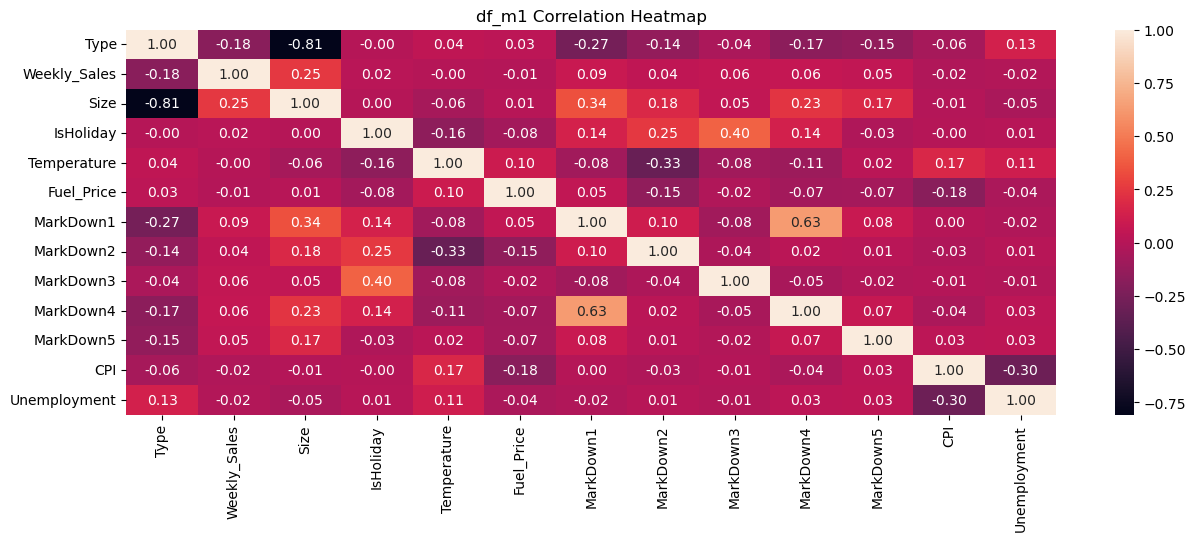

In [68]:

df_m1_corr = df_m1_weekly_sales.drop(columns=['Day', 'Month', 'Year', 'Store', 'Dept']).dropna().corr(numeric_only=True)

# Create a heatmap
plt.figure(figsize=(15, 5))
sns.heatmap(df_m1_corr, annot=True, fmt=".2f")
plt.title("df_m1 Correlation Heatmap")
plt.show()

In [70]:
# filter null values into separate dataframe and reset index order
df_null = df_m1[df_m1['Weekly_Sales'].isnull()]
df_null.reset_index(drop=True, inplace=True)

# also filter non-null values into separate dataframe and reset index order
df_notnull = df_m1[df_m1['Weekly_Sales'].notnull()]
df_notnull.reset_index(drop=True, inplace=True)

# make vector(x) and label(y) variables
x = df_notnull.drop(columns=['Weekly_Sales', 'diff'], axis=1)
y = df_notnull['Weekly_Sales']
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

# Random Forest algorithm performs well to predict unseen data
model = RandomForestRegressor().fit(x_train, y_train)
y_pred = model.predict(x_test)

# evaluate model performance using metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

metrics = {'R2': r2,
           'Mean Absolute Error': mae,
           'Mean Squared Error': mse,
           'Root Mean Squared Error': rmse}

print(metrics)

{'R2': 0.9743328036785303, 'Mean Absolute Error': 1427.4690117856333, 'Mean Squared Error': 13011882.61681318, 'Root Mean Squared Error': np.float64(3607.1987215584863)}


In [71]:
import pickle

# save the model to pickle
with open("model1_markdown.pkl", 'wb') as f:
    pickle.dump(model, f)

Method 2 - w/o Markdown


In [72]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor



In [73]:
# Processing steps:
# - Build a DataFrame using non-null records only.
# - Train a model to predict 'CPI'.
# - Repeat the process for 'Unemployment'.
# - Use the completed dataset to train the final 'Weekly_Sales' prediction model.


In [74]:

def algorithm_train_test_accuracy(x_train, x_test, y_train, y_test, algorithm):

    model = algorithm().fit(x_train, y_train)
    y_pred_train = model.predict(x_train)
    y_pred_test = model.predict(x_test)
    r2_train = r2_score(y_train, y_pred_train)
    r2_test = r2_score(y_test, y_pred_test)

    # algo = str(algorithm).split("'")[1].split(".")[-1]
    accuracy = {'algorithm': algorithm.__name__,
                'R2_train' : r2_train,
                'R2_test'  : r2_test}

    return accuracy



In [75]:


# check different algorithms and predict null values using best algorithm 

def ml_regression(df, null_features, label):

    # only label column       h null values and drop the other null columns from df
    df = df.drop(columns=null_features)

    # filter null values into separate dataframe and reset index order
    df_null = df[df[label].isnull()]
    df_null.reset_index(drop=True, inplace=True)

    # also filter non-null values into separate dataframe and reset index order
    df_notnull = df[df[label].notnull()]
    df_notnull.reset_index(drop=True, inplace=True)

    # make vector(x) and label(y) variables
    x = df_notnull.drop(columns=[label, 'diff'], axis=1)
    y = df_notnull[label]
    x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

    # calculate Training and Testing accuracy of different algorithms and evaluate model performance using metrics
    print(algorithm_train_test_accuracy(x_train, x_test, y_train, y_test, DecisionTreeRegressor))
    # print(algorithm_train_test_accuracy(x_train, x_test, y_train, y_test, ExtraTreesRegressor))
    print(algorithm_train_test_accuracy(x_train, x_test, y_train, y_test, RandomForestRegressor))
    print(algorithm_train_test_accuracy(x_train, x_test, y_train, y_test, AdaBoostRegressor))  
    print(algorithm_train_test_accuracy(x_train, x_test, y_train, y_test, GradientBoostingRegressor))
    print(algorithm_train_test_accuracy(x_train, x_test, y_train, y_test, XGBRegressor))

    # Random Forest algorithm performs well to predict unseen data
    model = RandomForestRegressor().fit(x_train, y_train)
    y_pred = model.predict(x_test)

    # evaluate model performance using metrics
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)

    metrics = {'R2': r2,
              'Mean Absolute Error': mae,
              'Mean Squared Error': mse,
              'Root Mean Squared Error': rmse}
    print(metrics)

    # predict null values using model
    y_pred = model.predict(df_null.drop(columns=[label, 'diff'], axis=1))

    # make dataframe of predicted label value and merge with non-null values
    df_null[label] = pd.DataFrame(y_pred)
    df_final = pd.concat([df_null,df_notnull], axis=0, ignore_index=True)
    return df_final



In [76]:

df_m2 = df5.copy()
df_m2.drop(columns=['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5','markdown'],inplace=True)
df_m2.tail()



,Day,Month,Year,Store,Dept,Type,Weekly_Sales,Size,IsHoliday,Temperature,Fuel_Price,CPI,Unemployment,diff
551474,26,7,2013,45,94,2,NaN,118221,0,76.06,3.804,NaN,NaN,2672013-45-94
551475,26,7,2013,45,95,2,NaN,118221,0,76.06,3.804,NaN,NaN,2672013-45-95
551476,26,7,2013,45,96,2,NaN,118221,0,76.06,3.804,NaN,NaN,2672013-45-96
551477,26,7,2013,45,97,2,NaN,118221,0,76.06,3.804,NaN,NaN,2672013-45-97
551478,26,7,2013,45,98,2,NaN,118221,0,76.06,3.804,NaN,NaN,2672013-45-98


In [77]:
df_m2_cpi = ml_regression(df_m2, ['Weekly_Sales','Unemployment'], 'CPI')
df_m2_cpi



{'algorithm': 'DecisionTreeRegressor', 'R2_train': 1.0, 'R2_test': 1.0}
{'algorithm': 'ExtraTreesRegressor', 'R2_train': 1.0, 'R2_test': 0.9999999999999574}
{'algorithm': 'RandomForestRegressor', 'R2_train': 1.0, 'R2_test': 1.0}
{'algorithm': 'AdaBoostRegressor', 'R2_train': 0.4574187287919562, 'R2_test': 0.46032256792532045}
{'algorithm': 'GradientBoostingRegressor', 'R2_train': 0.9862542573066267, 'R2_test': 0.9861648920308032}
{'algorithm': 'XGBRegressor', 'R2_train': 0.9999780628791352, 'R2_test': 0.9999776129120562}
{'R2': 1.0, 'Mean Absolute Error': 2.0388569244323282e-13, 'Mean Squared Error': 5.661987057298025e-26, 'Root Mean Squared Error': np.float64(2.379493025267783e-13)}


,Day,Month,Year,Store,Dept,Type,Size,IsHoliday,Temperature,Fuel_Price,CPI,diff
0,3,5,2013,1,1,1,151315,0,66.66,3.386,225.156780,352013-1-1
1,3,5,2013,1,2,1,151315,0,66.66,3.386,225.156780,352013-1-2
2,3,5,2013,1,3,1,151315,0,66.66,3.386,225.156780,352013-1-3
3,3,5,2013,1,4,1,151315,0,66.66,3.386,225.156780,352013-1-4
4,3,5,2013,1,5,1,151315,0,66.66,3.386,225.156780,352013-1-5
...,...,...,...,...,...,...,...,...,...,...,...,...
551474,26,4,2013,45,94,2,118221,0,50.64,3.615,193.589304,2642013-45-94
551475,26,4,2013,45,95,2,118221,0,50.64,3.615,193.589304,2642013-45-95
551476,26,4,2013,45,96,2,118221,0,50.64,3.615,193.589304,2642013-45-96
551477,26,4,2013,45,97,2,118221,0,50.64,3.615,193.589304,2642013-45-97


In [78]:

# drop old 'CPI' column and merge the new predicted 'CPI' columns 

df_m2 = df_m2.drop(columns=['CPI'], axis=1)
df_m2 = pd.merge(df_m2, df_m2_cpi[['CPI', 'diff']], on='diff', how='inner')
df_m2.tail()



,Day,Month,Year,Store,Dept,Type,Weekly_Sales,Size,IsHoliday,Temperature,Fuel_Price,Unemployment,diff,CPI
551474,26,7,2013,45,94,2,NaN,118221,0,76.06,3.804,NaN,2672013-45-94,193.346824
551475,26,7,2013,45,95,2,NaN,118221,0,76.06,3.804,NaN,2672013-45-95,193.346824
551476,26,7,2013,45,96,2,NaN,118221,0,76.06,3.804,NaN,2672013-45-96,193.346824
551477,26,7,2013,45,97,2,NaN,118221,0,76.06,3.804,NaN,2672013-45-97,193.346824
551478,26,7,2013,45,98,2,NaN,118221,0,76.06,3.804,NaN,2672013-45-98,193.346824


In [79]:
df_m2_unemployment = ml_regression(df_m2, ['Weekly_Sales'], 'Unemployment')
df_m2_unemployment

{'algorithm': 'DecisionTreeRegressor', 'R2_train': 1.0, 'R2_test': 1.0}
{'algorithm': 'ExtraTreesRegressor', 'R2_train': 1.0, 'R2_test': 1.0}
{'algorithm': 'RandomForestRegressor', 'R2_train': 1.0, 'R2_test': 1.0}
{'algorithm': 'AdaBoostRegressor', 'R2_train': 0.44434325366263294, 'R2_test': 0.44548050662361294}
{'algorithm': 'GradientBoostingRegressor', 'R2_train': 0.9582788731215776, 'R2_test': 0.9583653918816167}
{'algorithm': 'XGBRegressor', 'R2_train': 0.999582817912271, 'R2_test': 0.9995791177488755}
{'R2': 1.0, 'Mean Absolute Error': 2.14123216732645e-14, 'Mean Squared Error': 8.832739168418308e-28, 'Root Mean Squared Error': np.float64(2.971992457665111e-14)}


,Day,Month,Year,Store,Dept,Type,Size,IsHoliday,Temperature,Fuel_Price,Unemployment,diff,CPI
0,3,5,2013,1,1,1,151315,0,66.66,3.386,6.314,352013-1-1,225.156780
1,3,5,2013,1,2,1,151315,0,66.66,3.386,6.314,352013-1-2,225.156780
2,3,5,2013,1,3,1,151315,0,66.66,3.386,6.314,352013-1-3,225.156780
3,3,5,2013,1,4,1,151315,0,66.66,3.386,6.314,352013-1-4,225.156780
4,3,5,2013,1,5,1,151315,0,66.66,3.386,6.314,352013-1-5,225.156780
...,...,...,...,...,...,...,...,...,...,...,...,...,...
551474,26,4,2013,45,94,2,118221,0,50.64,3.615,8.335,2642013-45-94,193.589304
551475,26,4,2013,45,95,2,118221,0,50.64,3.615,8.335,2642013-45-95,193.589304
551476,26,4,2013,45,96,2,118221,0,50.64,3.615,8.335,2642013-45-96,193.589304
551477,26,4,2013,45,97,2,118221,0,50.64,3.615,8.335,2642013-45-97,193.589304


In [80]:


# drop old 'Unemployment' column and merge the new predicted 'Unemployment' columns

df_m2 = df_m2.drop(columns=['Unemployment'], axis=1)
df_m2 = pd.merge(df_m2, df_m2_unemployment[['Unemployment', 'diff']], on='diff', how='inner')
df_m2.tail()



,Day,Month,Year,Store,Dept,Type,Weekly_Sales,Size,IsHoliday,Temperature,Fuel_Price,diff,CPI,Unemployment
551474,26,7,2013,45,94,2,NaN,118221,0,76.06,3.804,2672013-45-94,193.346824,8.67618
551475,26,7,2013,45,95,2,NaN,118221,0,76.06,3.804,2672013-45-95,193.346824,8.67618
551476,26,7,2013,45,96,2,NaN,118221,0,76.06,3.804,2672013-45-96,193.346824,8.67618
551477,26,7,2013,45,97,2,NaN,118221,0,76.06,3.804,2672013-45-97,193.346824,8.67618
551478,26,7,2013,45,98,2,NaN,118221,0,76.06,3.804,2672013-45-98,193.346824,8.67618


In [81]:
# to predict 'Weekly_Sales'

df_m2_weekly_sales = ml_regression(df_m2, [], 'Weekly_Sales')
df_m2_weekly_sales



{'algorithm': 'DecisionTreeRegressor', 'R2_train': 1.0, 'R2_test': 0.9575995581025205}
{'algorithm': 'ExtraTreesRegressor', 'R2_train': 0.9999999999587131, 'R2_test': 0.9794344504987643}
{'algorithm': 'RandomForestRegressor', 'R2_train': 0.9966539850781064, 'R2_test': 0.9771875285887441}
{'algorithm': 'AdaBoostRegressor', 'R2_train': 0.026014408027792313, 'R2_test': 0.010520277375341891}
{'algorithm': 'GradientBoostingRegressor', 'R2_train': 0.7378815875869384, 'R2_test': 0.7394838834985393}
{'algorithm': 'XGBRegressor', 'R2_train': 0.9441643238126041, 'R2_test': 0.9418307154513301}
{'R2': 0.9767816904541603, 'Mean Absolute Error': 1357.4155085004106, 'Mean Squared Error': 11770429.250918694, 'Root Mean Squared Error': np.float64(3430.8059185734614)}


,Day,Month,Year,Store,Dept,Type,Weekly_Sales,Size,IsHoliday,Temperature,Fuel_Price,diff,CPI,Unemployment
0,5,2,2010,6,47,1,103.4468,202505,0,40.43,2.572,522010-6-47,212.622352,7.259
1,5,2,2010,9,49,2,28.2496,125833,0,38.01,2.572,522010-9-49,214.655459,6.415
2,5,2,2010,11,19,1,402.1142,207499,0,46.04,2.572,522010-11-19,214.424881,7.368
3,5,2,2010,15,80,2,53.2264,123737,0,19.83,2.954,522010-15-80,131.527903,8.350
4,5,2,2010,20,19,1,243.3656,203742,0,25.92,2.784,522010-20-19,204.247194,8.187
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
551474,26,10,2012,45,93,2,2487.8000,118221,0,58.85,3.882,26102012-45-93,192.308899,8.667
551475,26,10,2012,45,94,2,5203.3100,118221,0,58.85,3.882,26102012-45-94,192.308899,8.667
551476,26,10,2012,45,95,2,56017.4700,118221,0,58.85,3.882,26102012-45-95,192.308899,8.667
551477,26,10,2012,45,97,2,6817.4800,118221,0,58.85,3.882,26102012-45-97,192.308899,8.667


In [82]:
df_m2_weekly_sales.describe().T

,count,mean,std,min,25%,50%,75%,max
Day,551479.0,15.653488,8.776044,1.000,8.000000,16.00000,23.000000,31.000000
Month,551479.0,6.277180,3.340134,1.000,3.000000,6.00000,9.000000,12.000000
Year,551479.0,2011.392758,1.054086,2010.000,2010.000000,2011.00000,2012.000000,2013.000000
Store,551479.0,22.270485,12.796872,1.000,11.000000,22.00000,33.000000,45.000000
Dept,551479.0,44.603013,30.416079,1.000,19.000000,38.00000,74.000000,99.000000
Type,551479.0,1.594791,0.669624,1.000,1.000000,1.00000,2.000000,3.000000
Weekly_Sales,551479.0,15637.731980,22689.158863,0.010,1829.820000,7241.78000,19773.437550,693099.360000
Size,551479.0,136073.691863,61207.331445,34875.000,93638.000000,128107.00000,202505.000000,219622.000000
IsHoliday,551479.0,0.071905,0.258330,0.000,0.000000,0.00000,0.000000,1.000000
Temperature,551479.0,58.703624,18.685408,-7.290,45.160000,59.94000,73.160000,101.950000


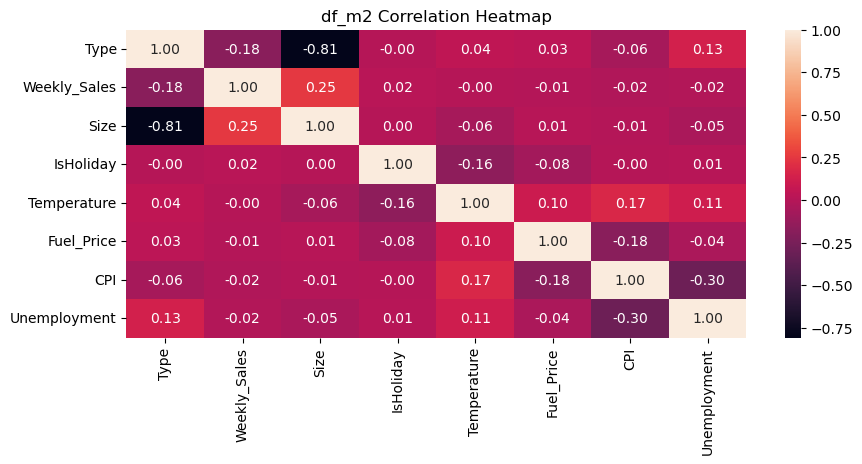

In [83]:

df_m2_corr = df_m2_weekly_sales.drop(columns=['Day', 'Month', 'Year', 'Store', 'Dept'], errors='ignore').dropna().corr(numeric_only=True)

plt.figure(figsize=(10, 4))  # Adjust the figure size if needed
sns.heatmap(df_m2_corr, annot=True, fmt=".2f")
plt.title("df_m2 Correlation Heatmap")
plt.show()


In [85]:


# filter null values into separate dataframe and reset index order
df_null = df_m2[df_m2['Weekly_Sales'].isnull()]
df_null.reset_index(drop=True, inplace=True)

# also filter non-null values into separate dataframe and reset index order
df_notnull = df_m2[df_m2['Weekly_Sales'].notnull()]
df_notnull.reset_index(drop=True, inplace=True)

# make vector(x) and label(y) variables
x = df_notnull.drop(columns=['Weekly_Sales', 'diff'], axis=1)
y = df_notnull['Weekly_Sales']
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

# Random Forest algorithm performs well to predict unseen data
model = RandomForestRegressor().fit(x_train, y_train)
y_pred = model.predict(x_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

metrics = {'R2': r2,
           'Mean Absolute Error': mae,
           'Mean Squared Error': mse,
           'Root Mean Squared Error': rmse}
print(metrics)



{'R2': 0.9765729158862666, 'Mean Absolute Error': 1360.4530885915544, 'Mean Squared Error': 11876266.683912307, 'Root Mean Squared Error': np.float64(3446.1959729406435)}


In [86]:

import pickle

# save the model to pickle
with open(r"model\model2.pkl", 'wb') as f:
    pickle.dump(model, f)



In [87]:
import pickle, os
os.makedirs('checkpoint', exist_ok=True)

# Save all key dataframes + variables in one go
checkpoint = {
    'df5': df5,
    'df_m1': df_m1,
    'df_m2': df_m2,
    'df_m1_weekly_sales': df_m1_weekly_sales,
    'df_m2_weekly_sales': df_m2_weekly_sales,
}

with open('checkpoint/pipeline_checkpoint.pkl', 'wb') as f:
    pickle.dump(checkpoint, f)

print("Checkpoint saved! Size:", os.path.getsize('checkpoint/pipeline_checkpoint.pkl') / (1024*1024), "MB")

Checkpoint saved! Size: 327.9735231399536 MB
